<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/Lab%204%20-%20task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Selected Voiced Frame Index: 108 (Time: 1.08s)
Selected Unvoiced Frame Index: 6 (Time: 0.06s)


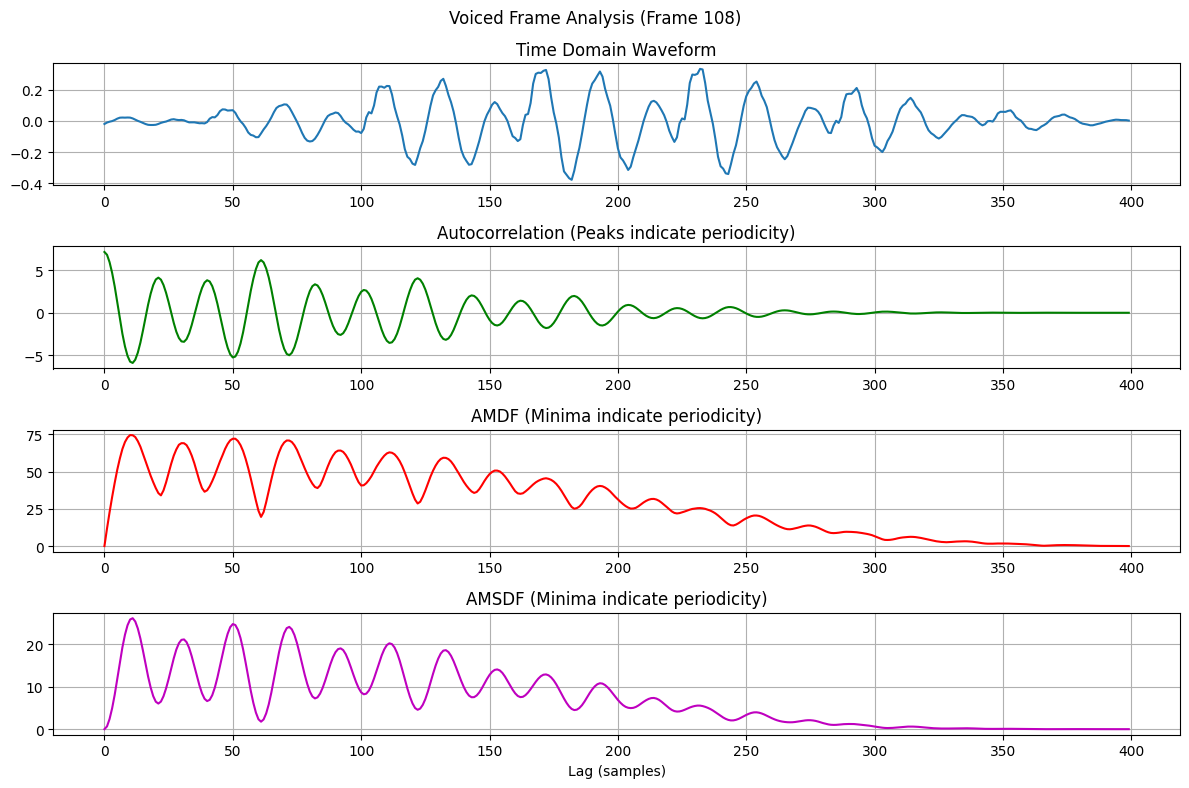

Observation (Voiced): Look for prominent peaks in Autocorr and deep valleys in AMDF/AMSDF at regularly spaced lags (Pitch Period).


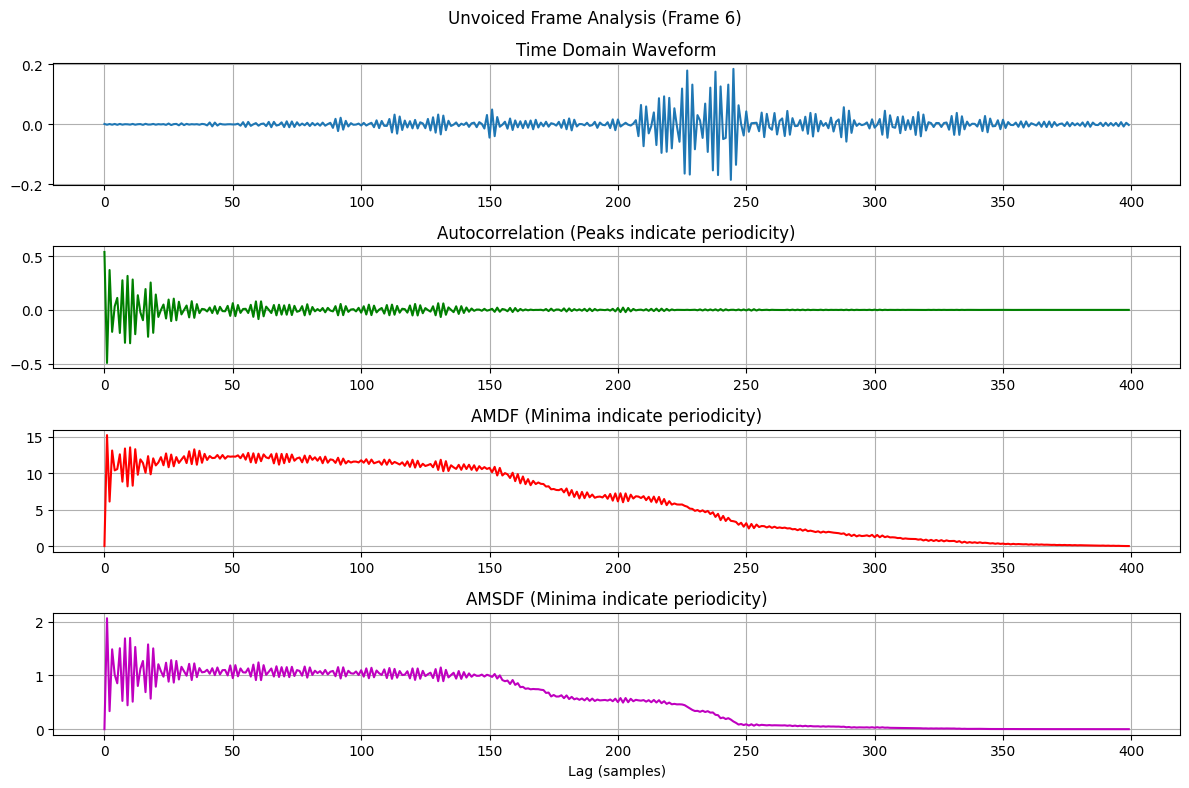

Observation (Unvoiced): Random fluctuations without regularly spaced strong peaks/valleys.


In [ ]:
# ==========================================
# TASK 2: PERIODICITY ANALYSIS (Autocorr, AMDF, AMSDF)
# ==========================================

# 1. SETUP
# ------------------------------------------
# Re-use variables from Task 1 (y, frames, sr, frame_len_samples)
# We will manually pick two indices: one likely voiced, one likely unvoiced based on ZCR/Energy plots
# Or we can detect them automatically.

def compute_full_functions(frame):
    """Computes full vectors for Autocorr, AMDF, AMSDF for a single frame."""
    n = len(frame)
    K = n  # Max lag to check

    # 1. Autocorrelation
    # r(k) = sum(x(m) * x(m+k))
    ac = np.correlate(frame, frame, mode='full')
    ac = ac[n-1:] # Keep non-negative lags

    # 2. AMDF & AMSDF
    amdf = np.zeros(K)
    amsdf = np.zeros(K)

    for k in range(K):
        # Difference between frame and shifted version
        # frame[0:N-k] vs frame[k:N]
        diff = np.abs(frame[:n-k] - frame[k:])
        amdf[k] = np.sum(diff)
        amsdf[k] = np.sum(diff**2)

    return ac, amdf, amsdf

# 2. SELECT FRAMES
# ------------------------------------------
# Automatic selection:
# Voiced: High Energy, Low ZCR
# Unvoiced: Low Energy, High ZCR

# STE and ZCR from Task 1 (using Hamming)
ste_norm = ste_ham / np.max(ste_ham)
zcr_norm = zcr_ham / np.max(zcr_ham)

# Find index of max energy (likely voiced vowel)
voiced_idx = np.argmax(ste_norm)

# Find index of high ZCR (likely unvoiced fricative)
# We look for high ZCR but exclude silence (where energy is near 0)
mask_silence = ste_norm > 0.05
unvoiced_candidates = np.where((zcr_norm > 0.3) & mask_silence)[0]
unvoiced_idx = unvoiced_candidates[0] if len(unvoiced_candidates) > 0 else np.argmax(zcr_norm)

print(f"Selected Voiced Frame Index: {voiced_idx} (Time: {voiced_idx*0.01:.2f}s)")
print(f"Selected Unvoiced Frame Index: {unvoiced_idx} (Time: {unvoiced_idx*0.01:.2f}s)")

# 3. COMPUTE & PLOT
# ------------------------------------------
indices = [("Voiced", voiced_idx), ("Unvoiced", unvoiced_idx)]

for label, idx in indices:
    frame = hamming_frames[idx]
    ac, amdf, amsdf = compute_full_functions(frame)
    lags = np.arange(len(ac))

    plt.figure(figsize=(12, 8))
    plt.suptitle(f"{label} Frame Analysis (Frame {idx})")

    # Waveform
    plt.subplot(4, 1, 1)
    plt.plot(frame)
    plt.title("Time Domain Waveform")
    plt.grid()

    # Autocorrelation
    plt.subplot(4, 1, 2)
    plt.plot(lags, ac, color='g')
    plt.title("Autocorrelation (Peaks indicate periodicity)")
    plt.grid()

    # AMDF
    plt.subplot(4, 1, 3)
    plt.plot(lags, amdf, color='r')
    plt.title("AMDF (Minima indicate periodicity)")
    plt.grid()

    # AMSDF
    plt.subplot(4, 1, 4)
    plt.plot(lags, amsdf, color='m')
    plt.title("AMSDF (Minima indicate periodicity)")
    plt.xlabel("Lag (samples)")
    plt.grid()

    plt.tight_layout()
    plt.show()

    if label == "Voiced":
        print("Observation (Voiced): Look for prominent peaks in Autocorr and deep valleys in AMDF/AMSDF at regularly spaced lags (Pitch Period).")
    else:
        print("Observation (Unvoiced): Random fluctuations without regularly spaced strong peaks/valleys.")


## (b) How Periodicity is Reflected in Autocorrelation, AMDF, and AMSDF

### Autocorrelation
The autocorrelation function $r(k) = \sum_{n} x(n)\,x(n+k)$ measures the similarity of a signal with a delayed version of itself.

- **Voiced (periodic) frame:** $r(k)$ has a large peak at lag $k = 0$ (self-similarity), and then **repeating prominent peaks** at lags $k = T_0, 2T_0, 3T_0, \ldots$, where $T_0$ is the pitch period. The spacing between peaks directly reveals the periodicity.
- **Unvoiced (aperiodic) frame:** $r(k)$ drops off rapidly and shows only **random, low-amplitude fluctuations** for $k > 0$ — no periodic peak structure exists.

### AMDF (Average Magnitude Difference Function)
$$\text{AMDF}(k) = \sum_{n=0}^{N-k-1} |x(n) - x(n+k)|$$

- **Voiced frame:** Because the signal repeats every $T_0$ samples, $x(n) \approx x(n + T_0)$, so the difference is near zero at $k = T_0$. This produces **deep, regularly-spaced minima** at multiples of the pitch period.
- **Unvoiced frame:** Differences are large and random at all lags — **no discernible minimum** pattern.

### AMSDF (Average Magnitude Squared Difference Function)
$$\text{AMSDF}(k) = \sum_{n=0}^{N-k-1} [x(n) - x(n+k)]^2$$

- Behaviour is identical to AMDF but the squaring emphasises large differences, making the **minima even deeper and sharper** for voiced speech — easier to locate programmatically.
- For unvoiced frames, AMSDF values are consistently large with no clear minimum.

---

## (c) Distinguishing Periodic (Voiced) vs Aperiodic (Unvoiced) Frames

| Criterion | Voiced (Periodic) Frame | Unvoiced (Aperiodic) Frame |
|---|---|---|
| **Waveform shape** | Smooth, quasi-sinusoidal; visually repeating pattern | Irregular, noise-like; no repeating pattern |
| **Autocorrelation** | Large, regularly-spaced peaks at multiples of pitch period | Only a peak at lag 0; rapid decay; no subsequent peaks |
| **AMDF** | Clear, deep minima at pitch-period multiples | High values throughout; no periodic dips |
| **AMSDF** | Sharp, deep minima (squaring amplifies contrast) | High, fluctuating values; no clear minima |
| **STE** | High | Low |
| **ZCR** | Low | High |

A frame is classified as **voiced** if the autocorrelation shows a prominent secondary peak in the lag range corresponding to 50–500 Hz (lags 32–320 at 16 kHz), or equivalently if AMDF/AMSDF shows a pronounced minimum in the same range. An **unvoiced** frame shows none of these structures.
